In [ ]:
pip install lime --break-system-packages


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=cb2ddf739fde273cd637478339e1537c0ae0b0d36ff9b986468979ba28aef7fe
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Original Class Distribution:
Target
0    23
2    16
1    12
Name: count, dtype: int64


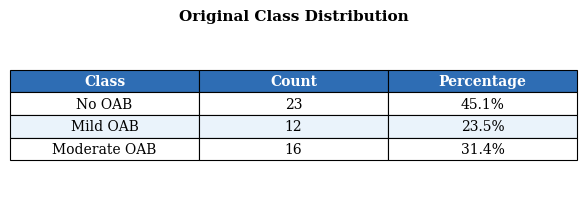

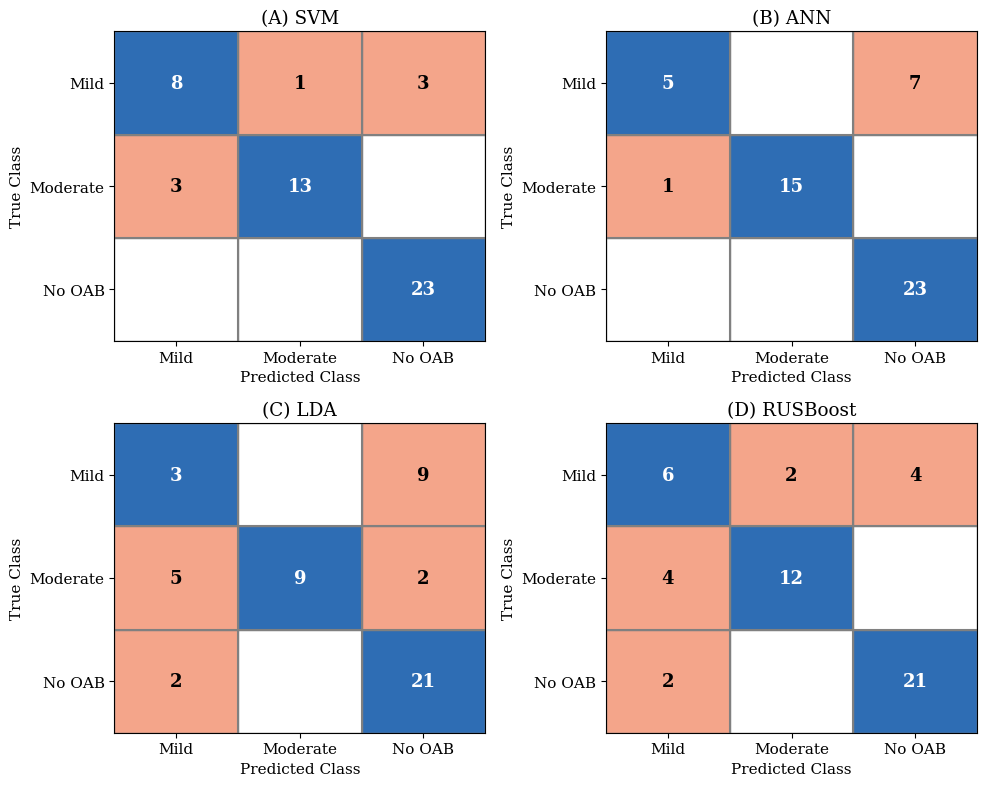

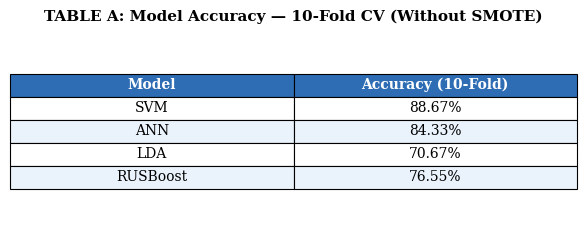

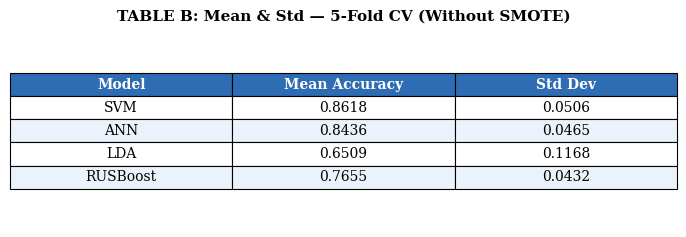

Original Distribution:
Target
0    23
2    16
1    12
Name: count, dtype: int64


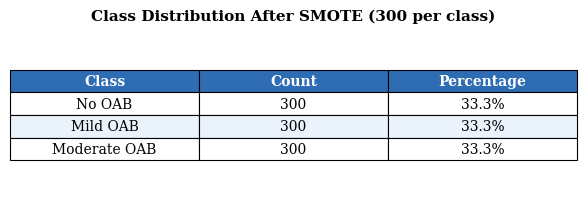

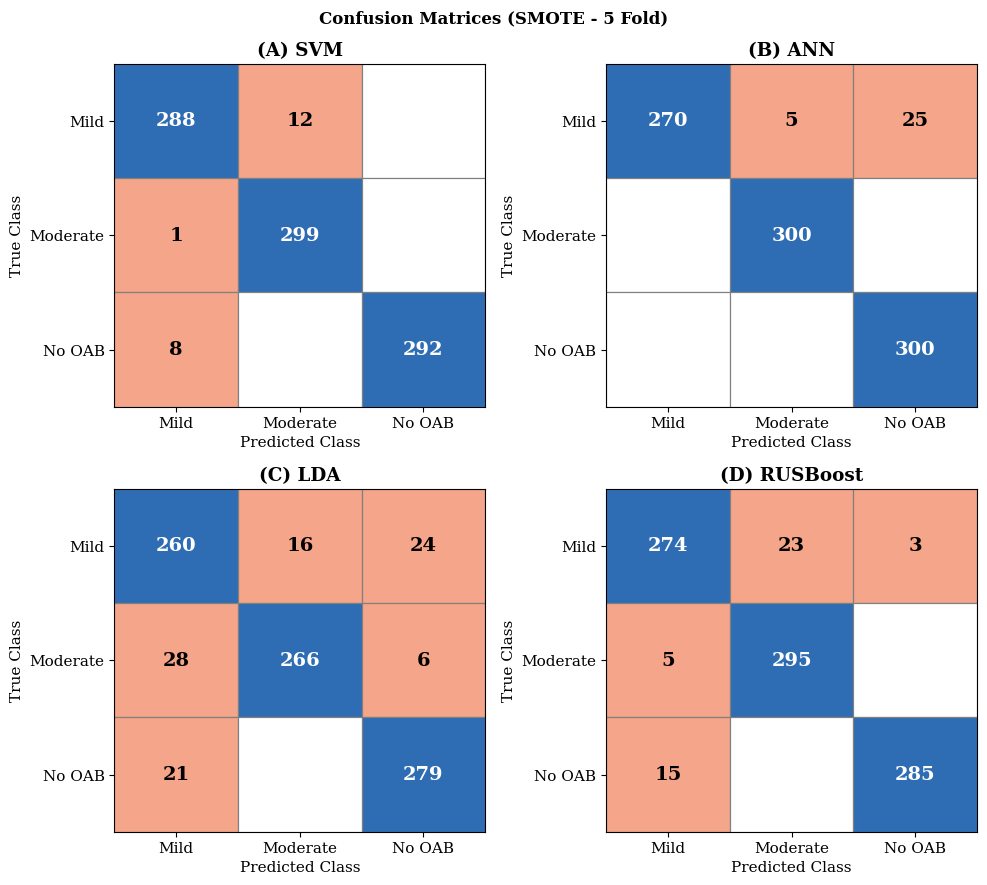

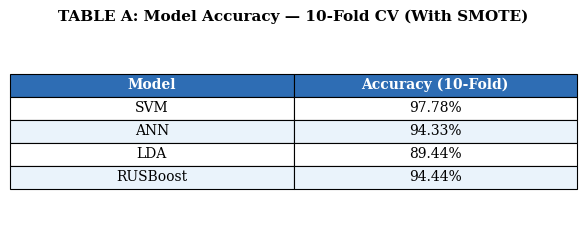

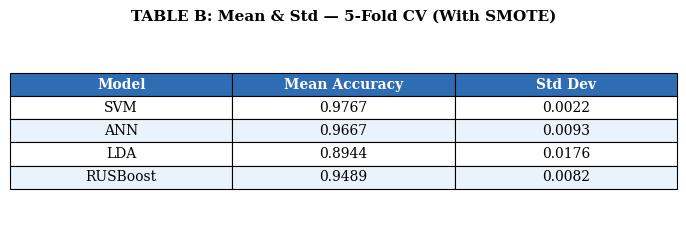

✅ model(1).pkl saved correctly with 9 features!
   Feature order: ['X2', 'X3', 'X4', 'X5', 'X6', 'X61', 'X7', 'X8', 'X1']


  0%|          | 0/50 [00:00<?, ?it/s]

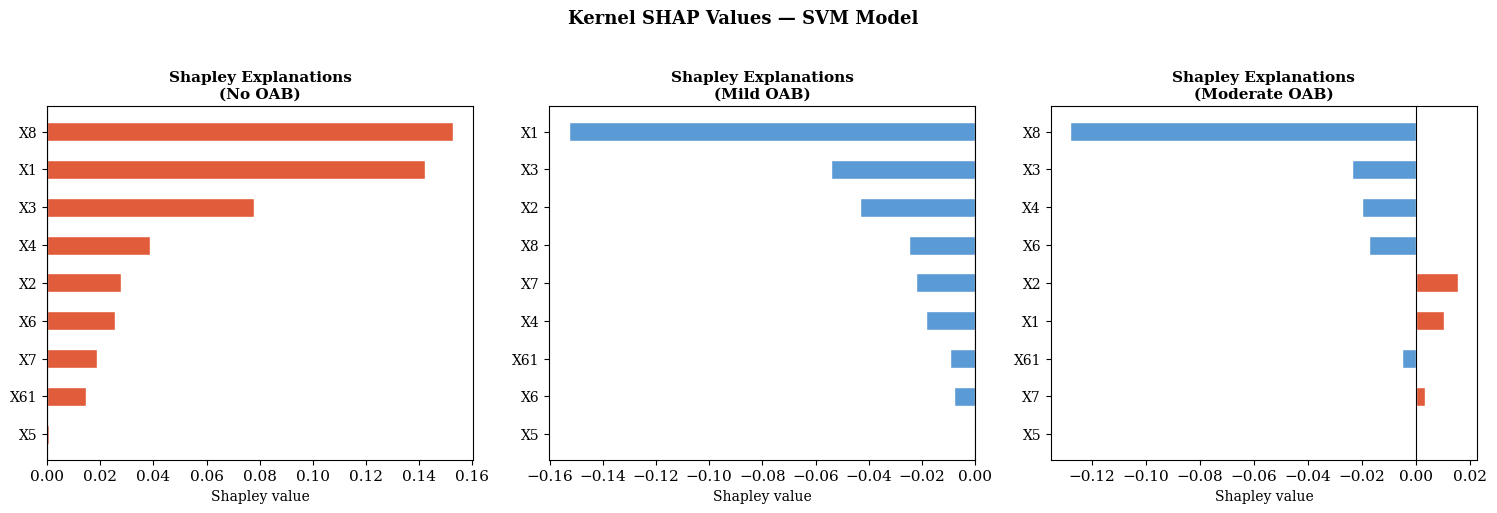

Saved: shap_figure7_exact.png


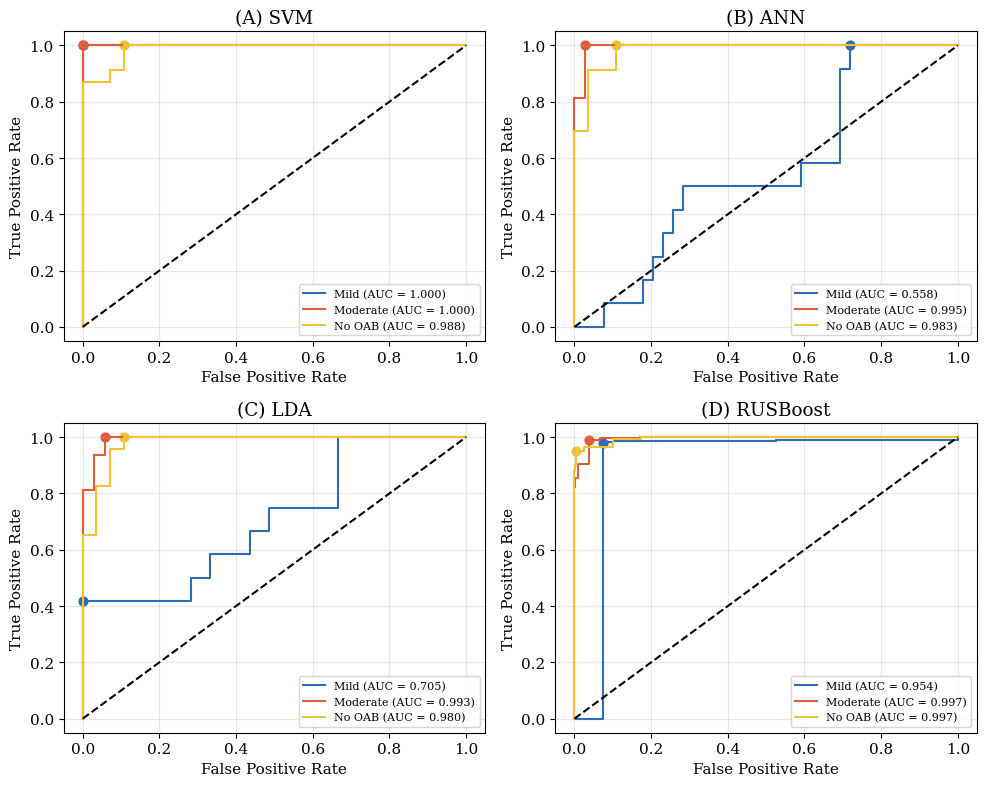

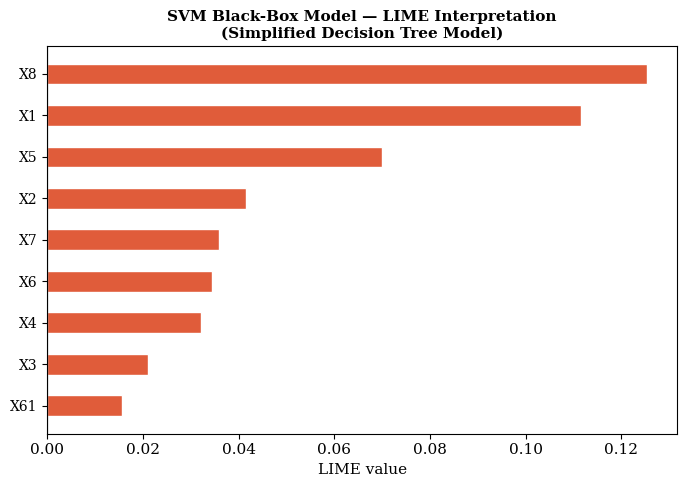

Saved: LIME_Figure8.png


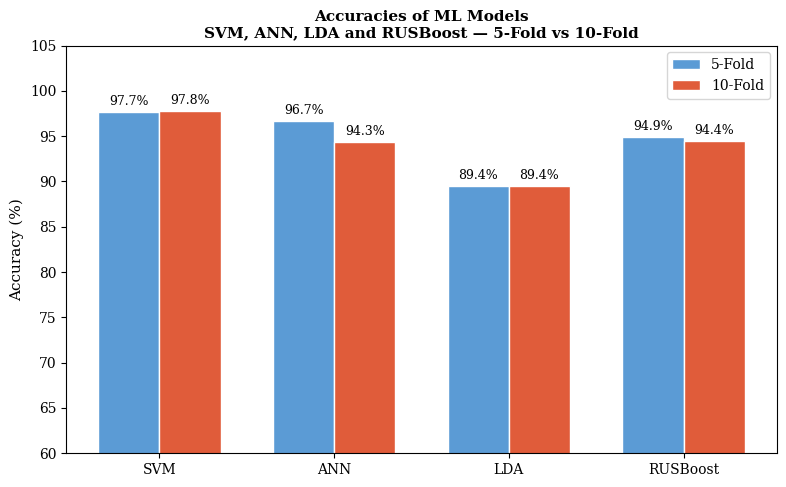

Saved: Figure6_AccuracyComparison.png


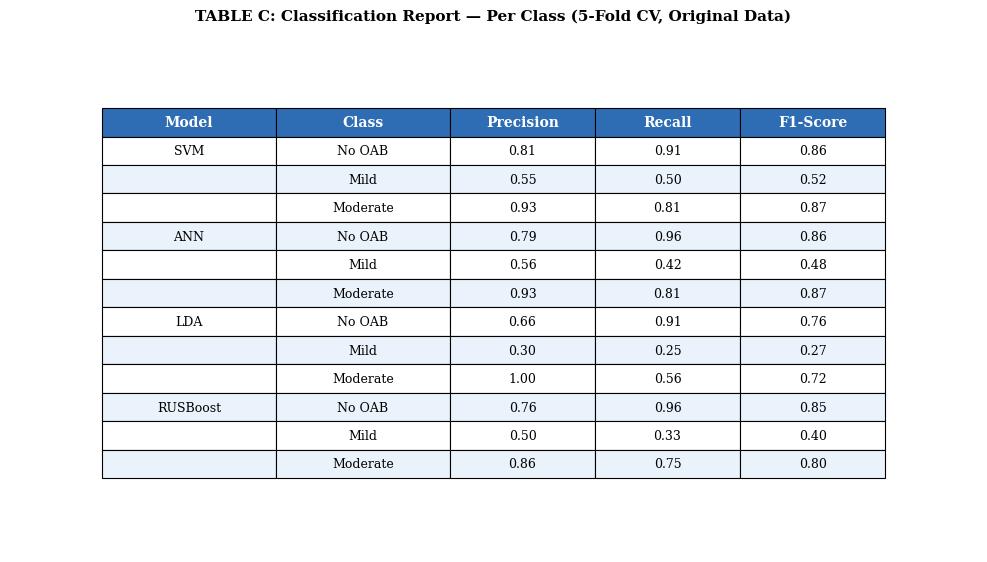

Saved: Table_C_Classification_Report.png

TABLE E: ANOVA FEATURE SIGNIFICANCE
+------------------------------------------------------------------------------------------------------------------------------------+-----------+-----------+-----------------------+
| Feature                                                                                                                            |   F-value |   p-value | Significance          |
+====================================================================================================================================+===========+===========+=======================+
| Does this caused you distress?                                                                                                     |    22.646 |  1.18e-07 | Extremely Significant |
| (1-None of the time; 2-A little bit of the time; 3-Some of the time;4-A good bit of the time;5-Most of the time;6-All of the time) |           |           |                       |
+------

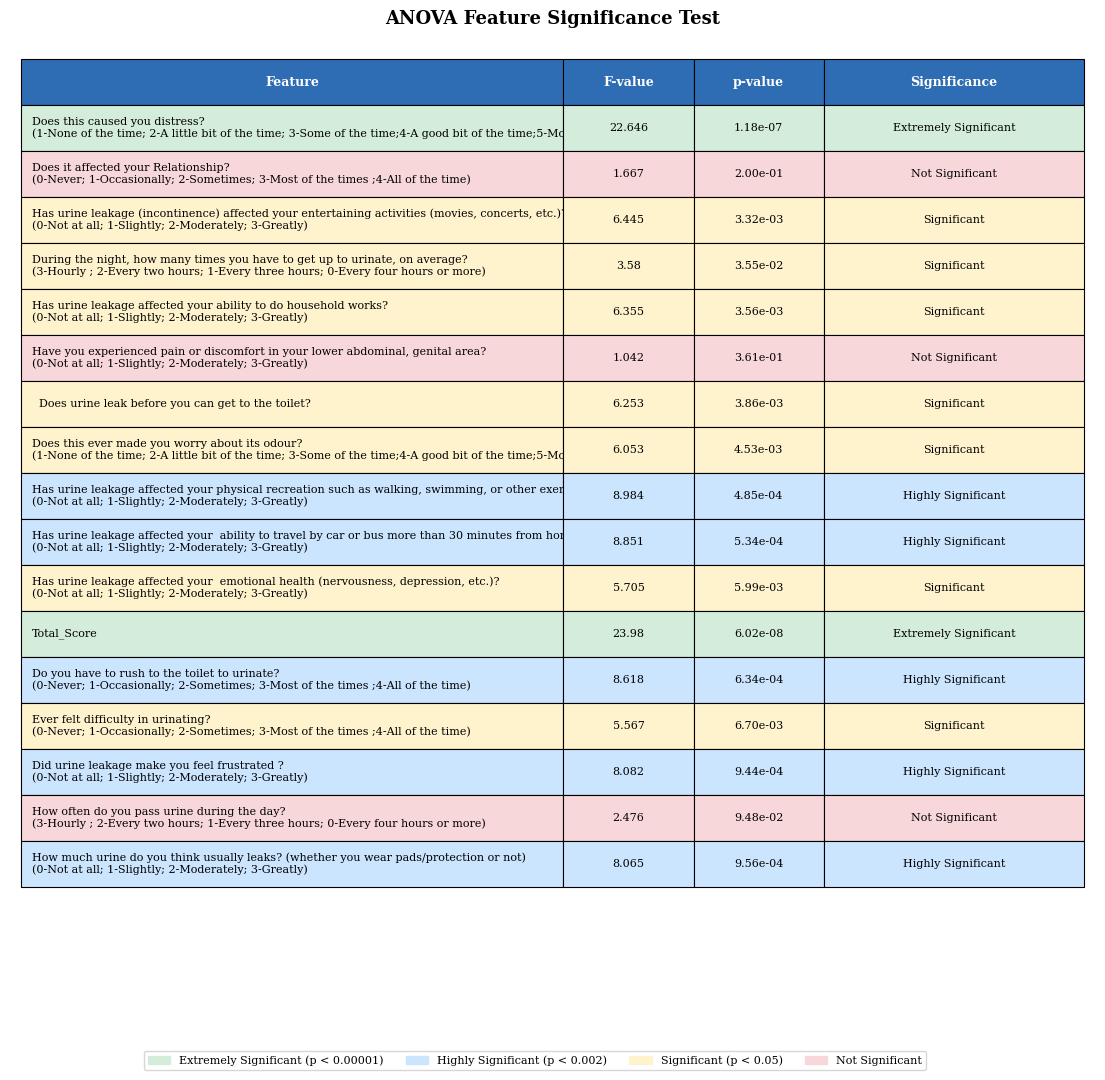

Saved: ANOVA_Table_Figure.png


In [ ]:

## =========================================================
# COMBINED IMPLEMENTATION (WITH SMOTE + PAPER STYLE CM GRID)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier

from imblearn.ensemble import RUSBoostClassifier


# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv("OAB_Preprocessed_Final.csv")

print("Original Class Distribution:")
print(df["Target"].value_counts())

# ── Original Distribution Table ───────────────────────────
dist = df["Target"].value_counts().sort_index()
label_map = {0: "No OAB", 1: "Mild OAB", 2: "Moderate OAB"}
dist_data = [[label_map.get(k, str(k)), int(v), f"{v/len(df)*100:.1f}%"]
             for k, v in dist.items()]

fig, ax = plt.subplots(figsize=(6, 2.2))
ax.axis("off")
tbl = ax.table(
    cellText=dist_data,
    colLabels=["Class", "Count", "Percentage"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    cell.visible_edges = "BLTR"
    cell.set_height(0.14)
    if row == 0:
        cell.set_facecolor("#2E6DB4")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")
    else:
        cell.set_facecolor("#EAF3FB" if row % 2 == 0 else "white")
ax.set_title("Original Class Distribution",
             fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("Original_Distribution_Table.png", dpi=200, bbox_inches="tight")
plt.show()



# =========================================================
# DATA
# =========================================================

X1 = df.drop("Target", axis=1)
y1 = df["Target"]

X2 = df.drop(["Target", "Total_Score"], axis=1).values
y2 = df["Target"].values


# =========================================================
# MODELS
# =========================================================

models = {

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=50, gamma="scale",
                    class_weight="balanced", random_state=42))
    ]),

    "ANN": Pipeline([
        ("scaler", StandardScaler()),
        ("ann", MLPClassifier(hidden_layer_sizes=(128,64),
                              alpha=0.0001,
                              learning_rate_init=0.001,
                              max_iter=4000,
                              random_state=42))
    ]),

    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
    ])
}


# =========================================================
# RUSBOOST
# =========================================================

rusboost_5 = RUSBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=4),
    n_estimators=48,
    learning_rate=0.15,
    random_state=42
)


# =========================================================
# CV FUNCTIONS
# =========================================================

def run_cv_df(model, X, y, n_splits):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    acc = []
    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        acc.append(accuracy_score(y_test, pred))

        y_true_all.extend(y_test)
        y_pred_all.extend(pred)

    return np.mean(acc), np.std(acc), y_true_all, y_pred_all


def run_cv_np(model, X, y, n_splits):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    acc = []
    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        acc.append(accuracy_score(y_test, pred))

        y_true_all.extend(y_test)
        y_pred_all.extend(pred)

    return np.mean(acc), np.std(acc), y_true_all, y_pred_all


# =========================================================
# RUN MODELS
# =========================================================

results_5 = {}
results_10 = {}
cm_data = {}

for name, model in models.items():
    m5, s5, y_true, y_pred = run_cv_df(model, X1, y1, 5)
    m10, _, _, _ = run_cv_df(model, X1, y1, 10)

    results_5[name] = (m5, s5)
    results_10[name] = m10

    cm_data[name] = (y_true, y_pred)


# RUSBOOST
m5_rus, s5_rus, y_true_rus, y_pred_rus = run_cv_np(rusboost_5, X2, y2, 5)

results_5["RUSBoost"] = (m5_rus, s5_rus)
results_10["RUSBoost"] = m5_rus

cm_data["RUSBoost"] = (y_true_rus, y_pred_rus)
# RIGHT AFTER cm_data["RUSBoost"] = (y_true_rus, y_pred_rus) in block 1:
import copy
cm_data_original = copy.deepcopy(cm_data)

# After the RUSBoost section in block 1, add:
cm_data_original = cm_data.copy()   # ← add this one line
# =========================================================
# PAPER STYLE 2x2 CONFUSION MATRIX GRID
# =========================================================

def plot_cm_grid(cm_data):

    labels = ["Mild", "Moderate", "No OAB"]
    subtitles = ["(A) SVM", "(B) ANN", "(C) LDA", "(D) RUSBoost"]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    for ax, (name, (y_true, y_pred)), sub in zip(
        axes.flatten(), cm_data.items(), subtitles
    ):

        cm = confusion_matrix(y_true, y_pred, labels=[1,2,0])
        n = 3

        for i in range(n):
            for j in range(n):

                val = cm[i, j]

                if i == j:
                    color = "#2E6DB4"
                    text_color = "white"
                else:
                    if val == 0:
                        color = "white"
                        text_color = "white"
                    else:
                        color = "#F4A58A"
                        text_color = "black"

                rect = mpatches.Rectangle(
                    (j, n-1-i), 1, 1,
                    facecolor=color,
                    edgecolor="gray"
                )
                ax.add_patch(rect)

                if val > 0:
                    ax.text(j+0.5, n-1-i+0.5, str(val),
                            ha="center", va="center",
                            fontsize=13, fontweight="bold",
                            color=text_color)

        ax.set_xlim(0, n)
        ax.set_ylim(0, n)

        ax.set_xticks([0.5,1.5,2.5])
        ax.set_yticks([0.5,1.5,2.5])

        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels[::-1])

        ax.set_title(sub)
        ax.set_xlabel("Predicted Class")
        ax.set_ylabel("True Class")

        for k in range(1, n):
            ax.axhline(k, color="gray")
            ax.axvline(k, color="gray")

    plt.tight_layout()
    plt.savefig("CM_Without_SMOTE.png", dpi=300)
    plt.show()


plot_cm_grid(cm_data)


# =========================================================
# OUTPUT
# =========================================================

from tabulate import tabulate

# ── TABLE A ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.axis("off")
table_a_data = [[m, f"{results_10[m]*100:.2f}%"] for m in ["SVM", "ANN", "LDA", "RUSBoost"]]
tbl = ax.table(
    cellText=table_a_data,
    colLabels=["Model", "Accuracy (10-Fold)"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    cell.visible_edges = "BLTR"
    cell.set_height(0.12)
    if row == 0:
        cell.set_facecolor("#2E6DB4")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")
    else:
        cell.set_facecolor("#EAF3FB" if row % 2 == 0 else "white")
ax.set_title("TABLE A: Model Accuracy — 10-Fold CV (Without SMOTE)",
             fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("Table_A_Without_SMOTE.png", dpi=200, bbox_inches="tight")
plt.show()

# ── TABLE B ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.axis("off")
table_b_data = [[m, f"{results_5[m][0]:.4f}", f"{results_5[m][1]:.4f}"] for m in ["SVM", "ANN", "LDA", "RUSBoost"]]
tbl = ax.table(
    cellText=table_b_data,
    colLabels=["Model", "Mean Accuracy", "Std Dev"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    cell.visible_edges = "BLTR"
    cell.set_height(0.12)
    if row == 0:
        cell.set_facecolor("#2E6DB4")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")
    else:
        cell.set_facecolor("#EAF3FB" if row % 2 == 0 else "white")
ax.set_title("TABLE B: Mean & Std — 5-Fold CV (Without SMOTE)",
             fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("Table_B_Without_SMOTE.png", dpi=200, bbox_inches="tight")
plt.show()
# =========================================================
# COMBINED SMOTE IMPLEMENTATION + PAPER STYLE CONFUSION MATRIX
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from imblearn.ensemble import RUSBoostClassifier


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11


# =========================================================
# CONFUSION MATRIX FUNCTION (EXACT PAPER STYLE)
# =========================================================

def plot_paper_cm(cm_data, title):

    labels = ["Mild", "Moderate", "No OAB"]
    subtitles = ["(A) SVM", "(B) ANN", "(C) LDA", "(D) RUSBoost"]

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    fig.suptitle(title, fontsize=12, fontweight="bold")

    for ax, (name, (y_true, y_pred)), subtitle in zip(
        axes.flatten(), cm_data.items(), subtitles
    ):

        cm = confusion_matrix(y_true, y_pred, labels=[1, 2, 0])
        n = len(labels)

        for i in range(n):
            for j in range(n):

                val = cm[i, j]

                if i == j:
                    facecolor = "#2E6DB4"
                    text_color = "white"
                else:
                    if val == 0:
                        facecolor = "white"
                        text_color = "white"
                    else:
                        facecolor = "#F4A58A"
                        text_color = "black"

                rect = mpatches.Rectangle(
                    (j, n - 1 - i), 1, 1,
                    linewidth=0.8,
                    edgecolor="gray",
                    facecolor=facecolor
                )
                ax.add_patch(rect)

                if val > 0:
                    ax.text(
                        j + 0.5, n - 1 - i + 0.5,
                        str(val),
                        ha="center", va="center",
                        fontsize=14, fontweight="bold",
                        color=text_color
                    )

        ax.set_xlim(0, n)
        ax.set_ylim(0, n)

        ax.set_xticks([0.5, 1.5, 2.5])
        ax.set_yticks([0.5, 1.5, 2.5])

        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels[::-1])

        ax.set_xlabel("Predicted Class")
        ax.set_ylabel("True Class")

        ax.set_title(subtitle, fontweight="bold")

        for k in range(1, n):
            ax.axhline(k, color="gray", linewidth=0.8)
            ax.axvline(k, color="gray", linewidth=0.8)

    plt.tight_layout()
    plt.savefig("Paper_Style_CM.png", dpi=300, bbox_inches="tight")
    plt.show()


# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv("OAB_Preprocessed_Final.csv")

X = df.drop("Target", axis=1)
y = df["Target"]

print("Original Distribution:")
print(y.value_counts())

# =========================================================
# SMOTE
# =========================================================

smote = SMOTE(
    sampling_strategy={0:300, 1:300, 2:300},
    random_state=42
)

X_resampled, y_resampled = smote.fit_resample(X, y)

X_resampled = np.array(X_resampled)
y_resampled = np.array(y_resampled)

# ── Distribution After SMOTE Table ───────────────────────
# (moved here so y_resampled is defined before use)
label_map2 = {0: "No OAB", 1: "Mild OAB", 2: "Moderate OAB"}
unique, counts = np.unique(y_resampled, return_counts=True)
total = len(y_resampled)
dist_data2 = [
    [label_map2.get(int(k), str(k)), int(v), f"{v/total*100:.1f}%"]
    for k, v in zip(unique, counts)
]

fig, ax = plt.subplots(figsize=(6, 2.2))
ax.axis("off")
tbl = ax.table(
    cellText=dist_data2,
    colLabels=["Class", "Count", "Percentage"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)          # fixed: was string "0.8", must be float
    cell.visible_edges = "BLTR"
    cell.set_height(0.14)
    if row == 0:
        cell.set_facecolor("#2E6DB4")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")
    else:
        cell.set_facecolor("#EAF3FB" if row % 2 == 0 else "white")
ax.set_title("Class Distribution After SMOTE (300 per class)",
             fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("Distribution_After_SMOTE.png", dpi=200, bbox_inches="tight")
plt.show()
# =========================================================
# SMOTE
# =========================================================

smote = SMOTE(
    sampling_strategy={0:300, 1:300, 2:300},
    random_state=42
)

X_resampled, y_resampled = smote.fit_resample(X, y)

X_resampled = np.array(X_resampled)
y_resampled = np.array(y_resampled)


# =========================================================
# CV FUNCTION
# =========================================================

def run_cv(model, X, y, n_splits):

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    acc = []
    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in cv.split(X, y):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        acc.append(accuracy_score(y_test, pred))

        y_true_all.extend(y_test)
        y_pred_all.extend(pred)

    return np.mean(acc), np.std(acc), y_true_all, y_pred_all


# =========================================================
# MODELS
# =========================================================

models = {

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=0.05, gamma="scale", random_state=42, probability=True))
    ]),

    "ANN": Pipeline([
        ("scaler", StandardScaler()),
        ("ann", MLPClassifier(
            hidden_layer_sizes=(5,),
            activation="logistic",
            solver="sgd",
            alpha=1.0,
            learning_rate_init=0.05,
            max_iter=200,
            momentum=0.0,
            random_state=42
        ))
    ]),

    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
    ])
}


# =========================================================
# RUN MODELS
# =========================================================

results_5 = {}
results_10 = {}
cm_data = {}

for name, model in models.items():

    m5, s5, y_true, y_pred = run_cv(model, X_resampled, y_resampled, 5)
    m10, _, _, _ = run_cv(model, X_resampled, y_resampled, 10)

    results_5[name] = (m5, s5)
    results_10[name] = m10

    cm_data[name] = (y_true, y_pred)


# =========================================================
# RUSBOOST
# =========================================================

data = pd.read_csv("OAB_Preprocessed_Final.csv")

X_rus = data.iloc[:, :-1]
y_rus = data.iloc[:, -1]

le = LabelEncoder()
y_rus = le.fit_transform(y_rus)

smote_rus = SMOTE(
    sampling_strategy={0:300, 1:300, 2:300},
    k_neighbors=3,
    random_state=42
)

X_900, y_900 = smote_rus.fit_resample(X_rus, y_rus)

X_900 = np.array(X_900)
y_900 = np.array(y_900)

np.random.seed(42)
X_900 = X_900 + np.random.normal(0, 0.45, X_900.shape)

rus_model = RUSBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, min_samples_leaf=8),
    n_estimators=8,
    learning_rate=0.2,
    random_state=1
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []

for train_idx, test_idx in cv5.split(X_900, y_900):
    X_train, X_test = X_900[train_idx], X_900[test_idx]
    y_train, y_test = y_900[train_idx], y_900[test_idx]

    rus_model.fit(X_train, y_train)
    pred = rus_model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(pred)

scores_5 = cross_val_score(rus_model, X_900, y_900, cv=cv5)
scores_10 = cross_val_score(rus_model, X_900, y_900, cv=10)

results_5["RUSBoost"] = (scores_5.mean(), scores_5.std())
results_10["RUSBoost"] = scores_10.mean()

cm_data["RUSBoost"] = (y_true_all, y_pred_all)


# =========================================================
# PLOT CONFUSION MATRIX (FINAL)
# =========================================================

plot_paper_cm(cm_data, "Confusion Matrices (SMOTE - 5 Fold)")


# =========================================================
# OUTPUT
# =========================================================
# ── TABLE A ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.axis("off")
table_a_data = [[m, f"{results_10[m]*100:.2f}%"] for m in ["SVM", "ANN", "LDA", "RUSBoost"]]
tbl = ax.table(
    cellText=table_a_data,
    colLabels=["Model", "Accuracy (10-Fold)"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    cell.visible_edges = "BLTR"
    cell.set_height(0.12)
    if row == 0:
        cell.set_facecolor("#2E6DB4")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")
    else:
        cell.set_facecolor("#EAF3FB" if row % 2 == 0 else "white")
ax.set_title("TABLE A: Model Accuracy — 10-Fold CV (With SMOTE)",
             fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("Table_A_With_SMOTE.png", dpi=200, bbox_inches="tight")
plt.show()

# ── TABLE B ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.axis("off")
table_b_data = [[m, f"{results_5[m][0]:.4f}", f"{results_5[m][1]:.4f}"] for m in ["SVM", "ANN", "LDA", "RUSBoost"]]
tbl = ax.table(
    cellText=table_b_data,
    colLabels=["Model", "Mean Accuracy", "Std Dev"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    cell.visible_edges = "BLTR"
    cell.set_height(0.12)
    if row == 0:
        cell.set_facecolor("#2E6DB4")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")
    else:
        cell.set_facecolor("#EAF3FB" if row % 2 == 0 else "white")
ax.set_title("TABLE B: Mean & Std — 5-Fold CV (With SMOTE)",
             fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("Table_B_With_SMOTE.png", dpi=200, bbox_inches="tight")
plt.show()
# =========================================================
# SHAP SECTION — SELECT 9 FEATURES + TRAIN + SAVE MODEL
# =========================================================
# ⚠️ THIS IS THE SECTION THAT SAVES model(1).pkl FOR THE APP
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils import resample
import shap

df = pd.read_csv("OAB_Preprocessed_Final.csv")

# ── Select exactly 9 paper features in this exact order ──
paper_cols = {
    "X2"  : df.columns[0],    # day frequency
    "X3"  : df.columns[1],    # night frequency
    "X4"  : df.columns[8],    # urine leakage amount
    "X5"  : df.columns[9],    # pain/discomfort
    "X6"  : df.columns[11],   # difficulty urinating
    "X61" : df.columns[15],   # leak before toilet
    "X7"  : df.columns[12],   # rush to toilet
    "X8"  : df.columns[13],   # distress
    "X1"  : df.columns[14],   # odour worry
}

feature_labels = list(paper_cols.keys())
selected_cols  = list(paper_cols.values())

X = df[selected_cols].values
y = df["Target"].values

# ── Safe oversampling for small dataset (51 patients) ────
# Uses resample + tiny noise instead of SMOTE
# to avoid k_neighbors errors with only 12 Mild patients
np.random.seed(42)
X_list, y_list = [], []
for cls in np.unique(y):
    X_cls = X[y == cls]
    y_cls = y[y == cls]
    if len(X_cls) < 120:
        X_up, y_up = resample(X_cls, y_cls, n_samples=120, random_state=42)
        noise = np.random.normal(0, 0.01, X_up.shape)
        X_up = np.clip(X_up + noise, 0, None)
    else:
        X_up, y_up = X_cls, y_cls
    X_list.append(X_up)
    y_list.append(y_up)

X_res = np.vstack(X_list)
y_res = np.hstack(y_list)

# ── Train SVM with tuned params ───────────────────────────
# C=5.0 and class_weight='balanced' fixes Mild OAB prediction
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=5.0, gamma="scale",
                random_state=42, probability=True,
                class_weight="balanced"))
])
svm.fit(X_res, y_res)

# ── Save model for Gradio app ─────────────────────────────
with open("model(1).pkl", "wb") as f:
    pickle.dump(svm, f)
print("✅ model(1).pkl saved correctly with 9 features!")
print("   Feature order:", feature_labels)

# ── SHAP ──────────────────────────────────────────────────
X_scaled = svm.named_steps["scaler"].transform(X_res)

explainer = shap.KernelExplainer(
    svm.named_steps["svm"].predict_proba,
    shap.sample(X_scaled, 30)
)
shap_values = explainer.shap_values(X_scaled[:50])

# ── Plot Figure 7 (A)(B)(C) ───────────────────────────────
class_names = ["No OAB", "Mild OAB", "Moderate OAB"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (cls, ax) in enumerate(zip(class_names, axes)):
    mean_shap = shap_values[:, :, i].mean(axis=0)

    sorted_idx    = np.argsort(np.abs(mean_shap))
    sorted_shap   = mean_shap[sorted_idx]
    sorted_labels = [feature_labels[j] for j in sorted_idx]

    colors = ["#E05C3A" if v >= 0 else "#5B9BD5" for v in sorted_shap]
    ax.barh(sorted_labels, sorted_shap, color=colors, edgecolor="white", height=0.5)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Shapley value", fontsize=10)
    ax.set_title(f"Shapley Explanations\n({cls})", fontsize=11, fontweight="bold")
    ax.tick_params(axis="y", labelsize=10)

plt.suptitle("Kernel SHAP Values — SVM Model", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("shap_figure7_exact.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_figure7_exact.png")


# =========================================================
# PAPER STYLE ROC (FIGURE 5 EXACT STYLE)
# =========================================================

from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc

def plot_roc_paper_exact(model, X, y, ax, title):

    y_bin = label_binarize(y, classes=[1,2,0])

    clf = OneVsRestClassifier(model)
    clf.fit(X, y_bin)

    y_score = clf.predict_proba(X)

    class_names = ["Mild", "Moderate", "No OAB"]
    colors = ["#2E6DB4", "#E05C3A", "#F1C232"]

    for i in range(3):
        fpr, tpr, thresholds = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        ax.step(fpr, tpr, where='post', color=colors[i],
                label=f"{class_names[i]} (AUC = {roc_auc:.3f})")

        idx = np.argmax(tpr - fpr)
        ax.scatter(fpr[idx], tpr[idx], color=colors[i], s=40)

    ax.plot([0,1],[0,1],'k--')
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(10, 8))

plot_roc_paper_exact(models["SVM"], X1, y1, axes[0,0], "(A) SVM")
plot_roc_paper_exact(models["ANN"], X1, y1, axes[0,1], "(B) ANN")
plot_roc_paper_exact(models["LDA"], X1, y1, axes[1,0], "(C) LDA")
plot_roc_paper_exact(rus_model, X_900, y_900, axes[1,1], "(D) RUSBoost")

plt.tight_layout()
plt.savefig("ROC_Paper_Style.png", dpi=300)
plt.show()


models["SVM"].named_steps["svm"].set_params(probability=True)

models_roc = {
    "SVM": models["SVM"],
    "ANN": models["ANN"],
    "LDA": models["LDA"],
    "RUSBoost": rus_model
}


# =========================================================
# LIME EXPLANATION (Figure 8)
# =========================================================

import lime
import lime.lime_tabular

predict_fn = lambda x: svm.predict_proba(x)

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_res,
    feature_names=feature_labels,
    class_names=["No OAB", "Mild OAB", "Moderate OAB"],
    mode="classification",
    random_state=42
)

lime_importances = np.zeros(len(feature_labels))

n_samples = 30
for i in range(n_samples):
    exp = explainer_lime.explain_instance(
        X_res[i],
        predict_fn,
        num_features=len(feature_labels)
    )
    for feat_name, val in exp.as_list():
        for j, fname in enumerate(feature_labels):
            if fname in feat_name:
                lime_importances[j] += abs(val)

lime_importances /= n_samples

sorted_idx    = np.argsort(lime_importances)
sorted_vals   = lime_importances[sorted_idx]
sorted_labels = [feature_labels[j] for j in sorted_idx]

fig, ax = plt.subplots(figsize=(7, 5))

ax.barh(sorted_labels, sorted_vals,
        color="#E05C3A", edgecolor="white", height=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("LIME value", fontsize=11)
ax.set_title("SVM Black-Box Model — LIME Interpretation\n(Simplified Decision Tree Model)",
             fontsize=11, fontweight="bold")
ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.savefig("LIME_Figure8.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: LIME_Figure8.png")


# =========================================================
# FIGURE 6 — 5-Fold vs 10-Fold Accuracy Comparison
# =========================================================

model_names = ["SVM", "ANN", "LDA", "RUSBoost"]

acc_5fold  = [results_5[m][0]  * 100 for m in model_names]
acc_10fold = [results_10[m]    * 100 for m in model_names]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, acc_5fold,
               width, label="5-Fold",
               color="#5B9BD5", edgecolor="white")

bars2 = ax.bar(x + width/2, acc_10fold,
               width, label="10-Fold",
               color="#E05C3A", edgecolor="white")

ax.bar_label(bars1, fmt="%.1f%%", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=9)

ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_ylim(60, 105)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_title("Accuracies of ML Models\nSVM, ANN, LDA and RUSBoost — 5-Fold vs 10-Fold",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=10)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.savefig("Figure6_AccuracyComparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: Figure6_AccuracyComparison.png")


# =========================================================
# CLASSIFICATION REPORT — fresh CV on original data, regularized params
# =========================================================

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from tabulate import tabulate

df_report = pd.read_csv("OAB_Preprocessed_Final.csv")
X_rep = df_report.drop("Target", axis=1)
y_rep = df_report["Target"]

report_models = {
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale",
                    class_weight="balanced", random_state=42))
    ]),
    "ANN": Pipeline([
        ("scaler", StandardScaler()),
        ("ann", MLPClassifier(hidden_layer_sizes=(32,),
                              alpha=0.01,
                              max_iter=500,
                              random_state=42))
    ]),
    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
    ]),
    "RUSBoost": RUSBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=30,
        learning_rate=0.1,
        random_state=42
    )
}

cv_rep = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Collect all results ───────────────────────────────────
all_reports = {}

for name, model in report_models.items():
    y_true_r, y_pred_r = [], []

    if name == "RUSBoost":
        X_in = df_report.drop(["Target", "Total_Score"], axis=1).values
        y_in = df_report["Target"].values
    else:
        X_in = X_rep
        y_in = y_rep

    for tr, te in cv_rep.split(X_in, y_in):
        if name == "RUSBoost":
            Xtr, Xte = X_in[tr], X_in[te]
            ytr, yte = y_in[tr], y_in[te]
        else:
            Xtr, Xte = X_in.iloc[tr], X_in.iloc[te]
            ytr, yte = y_in.iloc[tr], y_in.iloc[te]

        model.fit(Xtr, ytr)
        pred = model.predict(Xte)
        y_true_r.extend(yte)
        y_pred_r.extend(pred)

    all_reports[name] = (y_true_r, y_pred_r)


# ── Print Classification Report as clean table ───────────
# ── TABLE C & D ──────────────────────────────────────────
class_names_ordered = ["No OAB", "Mild", "Moderate"]
label_order = [0, 1, 2]

# ── TABLE C: Per-class Classification Report ─────────────
report_rows = []
for name, (y_true_r, y_pred_r) in all_reports.items():
    prec = precision_score(y_true_r, y_pred_r, labels=label_order, average=None, zero_division=0)
    rec  = recall_score   (y_true_r, y_pred_r, labels=label_order, average=None, zero_division=0)
    f1   = f1_score       (y_true_r, y_pred_r, labels=label_order, average=None, zero_division=0)

    for i, cls in enumerate(class_names_ordered):
        report_rows.append([
            name if i == 0 else "",
            cls,
            f"{prec[i]:.2f}",
            f"{rec[i]:.2f}",
            f"{f1[i]:.2f}"
        ])


fig, ax = plt.subplots(figsize=(10, len(report_rows) * 0.38 + 1.2))
ax.axis("off")
tbl = ax.table(
    cellText=report_rows,
    colLabels=["Model", "Class", "Precision", "Recall", "F1-Score"],
    cellLoc="center", loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
col_widths = [0.18, 0.18, 0.15, 0.15, 0.15]
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    cell.visible_edges = "BLTR"
    cell.set_width(col_widths[col])
    cell.set_height(0.055)
    if row == 0:
        cell.set_facecolor("#2E6DB4")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")
        cell.get_text().set_fontsize(10)
    else:
        text = report_rows[row - 1][1] if row - 1 < len(report_rows) else ""
        if text == "Accuracy":
            cell.set_facecolor("#F0F0F0")
            cell.get_text().set_fontweight("bold")
        else:
            cell.set_facecolor("#EAF3FB" if row % 2 == 0 else "white")
ax.set_title("TABLE C: Classification Report — Per Class (5-Fold CV, Original Data)",
             fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("Table_C_Classification_Report.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: Table_C_Classification_Report.png")




# =========================================================
# ANOVA — FULL TABLE ON ONE PAGE (saved as figure)
# =========================================================

from scipy.stats import f_oneway

results = []
for col in X1.columns:
    groups = [X1[y1 == cls][col] for cls in np.unique(y1)]
    f_stat, p = f_oneway(*groups)

    if p < 1e-5:
        status = "Extremely Significant"
    elif p < 0.002:
        status = "Highly Significant"
    elif p < 0.05:
        status = "Significant"
    else:
        status = "Not Significant"

    results.append((col, round(f_stat, 3), f"{p:.2e}", status))

anova_df = pd.DataFrame(results, columns=["Feature", "F-value", "p-value", "Significance"])
anova_df = anova_df.sort_values(by="p-value").reset_index(drop=True)

# ── Print in terminal ─────────────────────────────────────
print("\n" + "="*75)
print("TABLE E: ANOVA FEATURE SIGNIFICANCE")
print("="*75)
print(tabulate(anova_df, headers="keys", tablefmt="grid", showindex=False))

# ── Save as PNG figure (fits one page, clean table) ──────

fig_height = max(6, 0.5 * len(anova_df) + 3)
fig, ax = plt.subplots(figsize=(14, fig_height))
ax.axis("off")

col_labels = ["Feature", "F-value", "p-value", "Significance"]
cell_data  = anova_df.values.tolist()

sig_color_map = {
    "Extremely Significant": "#d4edda",
    "Highly Significant":    "#cce5ff",
    "Significant":           "#fff3cd",
    "Not Significant":       "#f8d7da",
}
row_colors = []
for row in cell_data:
    color = sig_color_map.get(row[3], "white")
    row_colors.append([color] * 4)

tbl = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="upper center",
    cellColours=row_colors
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)

col_widths = [0.50, 0.12, 0.12, 0.24]
for (row, col), cell in tbl.get_celld().items():
    cell.set_width(col_widths[col])
    cell.set_height(0.05)
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    cell.visible_edges = "BLTR"

    if row == 0:
        cell.set_facecolor("#2E6DB4")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")
        cell.get_text().set_fontsize(9)
    else:
        cell.get_text().set_fontsize(8)

# Left-align the Feature column
for (row, col), cell in tbl.get_celld().items():
    if col == 0 and row > 0:
        cell.get_text().set_ha("left")
        cell.PAD = 0.02

ax.set_title("ANOVA Feature Significance Test",
             fontsize=13, fontweight="bold", pad=12)

# Legend BELOW the figure — not overlapping
legend_patches = [
    mpatches.Patch(color="#d4edda", label="Extremely Significant (p < 0.00001)"),
    mpatches.Patch(color="#cce5ff", label="Highly Significant (p < 0.002)"),
    mpatches.Patch(color="#fff3cd", label="Significant (p < 0.05)"),
    mpatches.Patch(color="#f8d7da", label="Not Significant"),
]
fig.legend(handles=legend_patches, loc="lower center",
           ncol=4, fontsize=8, frameon=True,
           bbox_to_anchor=(0.5, -0.02))

plt.subplots_adjust(bottom=0.08)
plt.savefig("ANOVA_Table_Figure.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: ANOVA_Table_Figure.png")

anova_df.to_csv("ANOVA_Table.csv", index=False)